### Optional dependency setup
Run this cell only if imports fail in your environment.

In [ ]:
import importlib.util

packages = [
    'numpy', 'matplotlib', 'plotly', 'ipywidgets', 'scipy', 'pandas', 'sklearn', 'seaborn'
]
missing = [p for p in packages if importlib.util.find_spec(p) is None]
if missing:
    print('Installing missing packages:', missing)
    get_ipython().run_line_magic('pip', 'install -q ' + ' '.join(missing))
else:
    print('All common packages already available.')


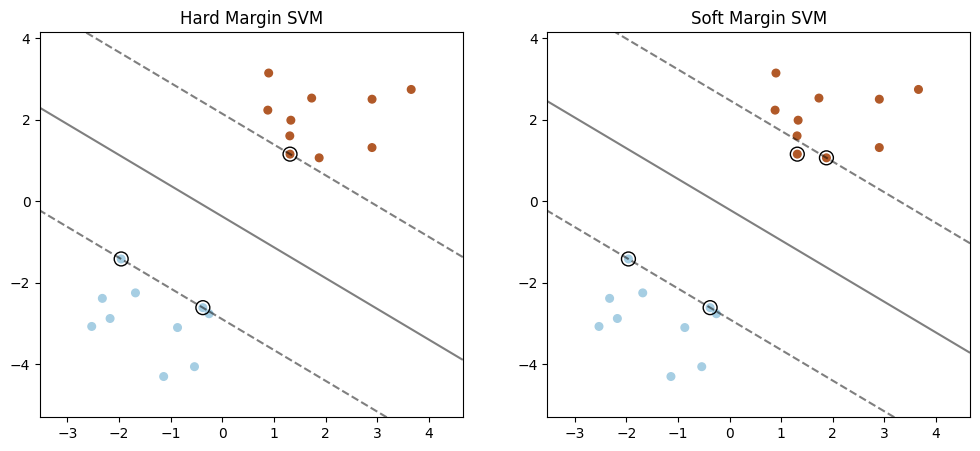

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# Generate a simple dataset
np.random.seed(1)
X = np.r_[np.random.randn(10, 2) - [2, 2], np.random.randn(10, 2) + [2, 2]]
Y = [0] * 10 + [1] * 10

# Fit the models
clf_hard = SVC(kernel='linear', C=1e10)  # Hard margin (C very large)
clf_soft = SVC(kernel='linear', C=0.1)   # Soft margin (C small)

clf_hard.fit(X, Y)
clf_soft.fit(X, Y)

# Function to plot SVM decision boundary
def plot_svm(clf, ax, inputs, labels, title):
    ax.scatter(inputs[:, 0], inputs[:, 1], c=labels, cmap=plt.cm.Paired, s=30)
    ax.set_xlim(inputs[:, 0].min() - 1, inputs[:, 0].max() + 1)
    ax.set_ylim(inputs[:, 1].min() - 1, inputs[:, 1].max() + 1)

    # Plot decision boundary and margins
    xx = np.linspace(inputs[:, 0].min() - 1, inputs[:, 0].max() + 1)
    yy = np.linspace(inputs[:, 1].min() - 1, inputs[:, 1].max() + 1)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = clf.decision_function(xy).reshape(XX.shape)

    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])

    ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=100,
               facecolors='none', edgecolors='k')
    ax.set_title(title)

# Create plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

plot_svm(clf_hard, ax1, X, Y, "Hard Margin SVM")
plot_svm(clf_soft, ax2, X, Y, "Soft Margin SVM")

plt.show()

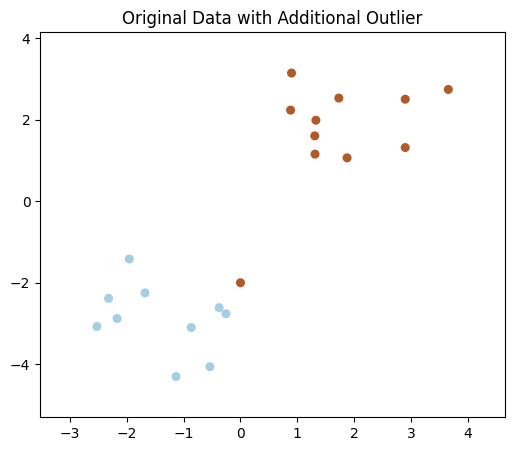

In [2]:
fig, (ax1) = plt.subplots(1, 1, figsize=(6, 5))

# Add an outlier to the dataset
X_outlier = np.vstack([X, [0, -2]])
Y_outlier = np.hstack([Y, [1]])

def plot_points_only(ax, inputs, labels, title):
  ax.scatter(inputs[:, 0], inputs[:, 1], c=labels, cmap=plt.cm.Paired, s=30)
  ax.set_xlim(inputs[:, 0].min() - 1, inputs[:, 0].max() + 1)
  ax.set_ylim(inputs[:, 1].min() - 1, inputs[:, 1].max() + 1)
  ax.set_title(title)

plot_points_only(ax1, X_outlier, Y_outlier, "Original Data with Additional Outlier")

plt.show()

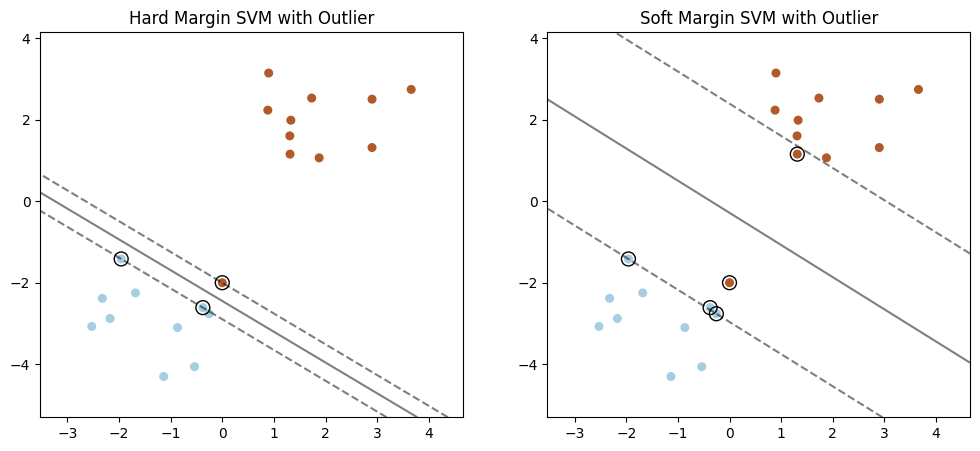

In [3]:
# Fit the models with the outlier
clf_hard_outlier = SVC(kernel='linear', C=1e10)
clf_soft_outlier = SVC(kernel='linear', C=0.1)

clf_hard_outlier.fit(X_outlier, Y_outlier)
clf_soft_outlier.fit(X_outlier, Y_outlier)

# Create plots with outlier
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

plot_svm(clf_hard_outlier, ax1, X_outlier, Y_outlier, "Hard Margin SVM with Outlier")
plot_svm(clf_soft_outlier, ax2, X_outlier, Y_outlier, "Soft Margin SVM with Outlier")

plt.show()


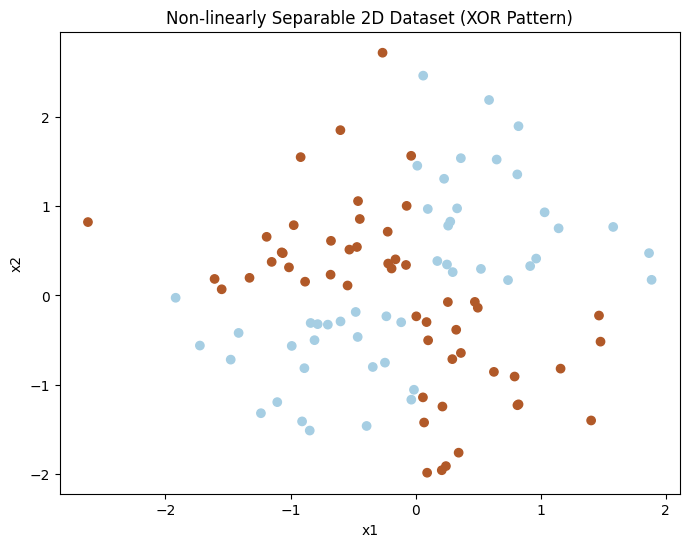

In [4]:
from mpl_toolkits.mplot3d import Axes3D

# Generate a non-linearly separable 2D dataset
np.random.seed(42)
n_samples = 100

# Generate data points in an XOR pattern
X = np.random.randn(n_samples, 2)
Y = np.logical_xor(X[:, 0] > 0, X[:, 1] > 0).astype(int)

# Plot the 2D dataset
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap=plt.cm.Paired)
plt.title("Non-linearly Separable 2D Dataset (XOR Pattern)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

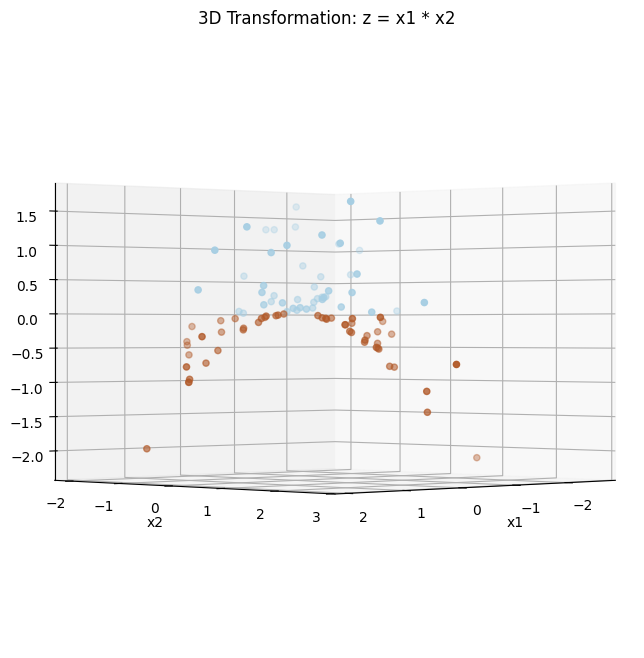

In [5]:
# 3D transformation of the dataset
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
Z = X[:, 0] * X[:, 1]  # z = xy
ax.scatter(X[:, 0], X[:, 1], Z, c=Y, cmap=plt.cm.Paired)
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("z = x1 * x2")
ax.set_title("3D Transformation: z = x1 * x2")
ax.view_init(elev=0, azim=45, roll=0)
plt.show()

## Interactive Controls\nUse the widget panel below to explore parameters live inside JupyterLite.\n

In [ ]:
# INTERACTIVE_WIDGET_SECTION\nimport numpy as np\nimport matplotlib.pyplot as plt\nimport ipywidgets as widgets\n\ndef _interactive_demo(freq=1.0, amp=1.0, phase=0.0):\n    x=np.linspace(-10,10,500)\n    y=amp*np.sin(freq*x+phase)\n    plt.figure(figsize=(8,4))\n    plt.plot(x,y,lw=2)\n    plt.grid(True)\n    plt.title('Interactive Demo Panel')\n    plt.show()\n\nwidgets.interact(_interactive_demo,\n    freq=widgets.FloatSlider(value=1.0,min=0.1,max=5.0,step=0.1),\n    amp=widgets.FloatSlider(value=1.0,min=0.1,max=3.0,step=0.1),\n    phase=widgets.FloatSlider(value=0.0,min=-3.14,max=3.14,step=0.1))\n